# Interactive Synthetic Data Creator

Create synthetic CO2 chamber measurements as JSON files. Start with the plain Python functions, then use the widget panel for interactive exploration.

## Setup

In [9]:
import contextlib
import copy
import datetime as dt
import io
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np

NOTEBOOK_DIR = pathlib.Path.cwd()
if not (NOTEBOOK_DIR / "02_interactive_synthetic_creator.ipynb").exists():
    NOTEBOOK_DIR = (pathlib.Path.cwd() / "notebooks" / "synthetic").resolve()

REPO_ROOT = NOTEBOOK_DIR.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from synthetic import Generator, Simulate_Sensor
from soilgasflux_fcs import models

DEFAULT_OUTPUT_DIR = NOTEBOOK_DIR / "generated"
DEFAULT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHAMBER = {
    "area": np.pi * 20**2 / 4,
    "volume": np.pi * 20**2 * 20 / 4,
}

SENSOR_PRESETS = {
    "perfect": None,
    "commercial": {
        "response_time": 10,
        "gas_analyzer_volume": 50,
        "sensor_accuracy": 0.1,
        "sensor_precision": 0.45,
        "pump_volume": 25,
        "pump_rate": 250,
        "additional_volume": 25,
        "with_diffusion": True,
        "with_advection": True,
    },
    "low-cost": {
        "response_time": 18,
        "gas_analyzer_volume": 120,
        "sensor_accuracy": 3.0,
        "sensor_precision": 1.0,
        "pump_volume": 40,
        "pump_rate": 120,
        "additional_volume": 80,
        "with_diffusion": True,
        "with_advection": True,
    },
}

## Plain Python Workflow

In [10]:
def make_ideal_config(
    total_time=180,
    c0=430.0,
    alpha=1.0e-4,
    cs=1.0e4,
    deadband=0,
    curvature="custom",
):
    generator = Generator(total_time=total_time, c0=c0)
    return generator.generate_base(
        alpha=alpha,
        cs=cs,
        c0=c0,
        t0=0,
        total_time=total_time,
        deadband=deadband,
        background_band=0,
        unmixed_phase=0,
        unmixed_disturbance_intensity=0,
        mixed_phase_disturbance=0,
        disturbance_intensity=0,
        disturbance_starting_point=0,
        add_noise=False,
        noise_intensity=0,
        curvature=curvature,
        noise_type=None,
    )


def apply_sensor_simulation(config, sensor_preset="low-cost", sensor_precision=None, random_seed=1):
    if sensor_preset == "perfect":
        simulated = copy.deepcopy(config)
        simulated["sensor_preset"] = "perfect"
        simulated["sensor_settings"] = None
        return simulated

    settings = copy.deepcopy(SENSOR_PRESETS[sensor_preset])
    if sensor_precision is not None:
        settings["sensor_precision"] = sensor_precision
    time = np.arange(config["total_time"])
    source_dcdt = models.hm_model_dcdt(
        t0=config["t0"],
        c0=config["c_c0"],
        a=config["alpha"],
        cx=config["c_s"],
        t=time,
    )

    simulator = Simulate_Sensor(
        alpha=config["alpha"],
        cs=config["c_s"],
        t0=config["t0"],
        c0=config["c_c0"],
        total_time=config["total_time"],
        dt=1,
    )

    state = np.random.get_state()
    np.random.seed(random_seed)
    try:
        with contextlib.redirect_stdout(io.StringIO()):
            simulator.chamber_settings(
                area=CHAMBER["area"],
                chamber_volume=CHAMBER["volume"],
            )
            simulator.gasAnalyzer_settings(
                response_time=settings["response_time"],
                gasAnalyzer_volume=settings["gas_analyzer_volume"],
                sensor_accuracy=settings["sensor_accuracy"],
                sensor_precision=settings["sensor_precision"],
            )
            simulator.internal_pump_settings(
                pump_volume=settings["pump_volume"],
                pump_rate=settings["pump_rate"],
            )
            simulator.additional_settings(volume=settings["additional_volume"])
            sensor_values = simulator.run_simulation(
                source_ppm=source_dcdt,
                with_diffusion=settings["with_diffusion"],
                with_advection=settings["with_advection"],
                verbose=False,
            )
    finally:
        np.random.set_state(state)

    simulated = copy.deepcopy(config)
    simulated["final_value"] = np.asarray(sensor_values, dtype=float)
    simulated["sensor_preset"] = sensor_preset
    simulated["sensor_settings"] = copy.deepcopy(settings)
    return simulated


def make_synthetic_config(
    total_time=180,
    c0=430.0,
    alpha=1.0e-4,
    cs=1.0e4,
    deadband=0,
    curvature="custom",
    sensor_preset="low-cost",
    sensor_precision=None,
    random_seed=1,
):
    ideal = make_ideal_config(
        total_time=total_time,
        c0=c0,
        alpha=alpha,
        cs=cs,
        deadband=deadband,
        curvature=curvature,
    )
    return apply_sensor_simulation(
        ideal,
        sensor_preset=sensor_preset,
        sensor_precision=sensor_precision,
        random_seed=random_seed,
    )


def preview_synthetic_config(config):
    time = np.arange(config["total_time"])
    values = np.asarray(config["final_value"], dtype=float)
    ideal = make_ideal_config(
        total_time=config["total_time"],
        c0=config["c_c0"],
        alpha=config["alpha"],
        cs=config["c_s"],
        deadband=config["deadband"],
        curvature=config["curvature"],
    )

    fig, ax = plt.subplots(figsize=(7, 3.5), dpi=120)
    ax.plot(time, ideal["final_value"], color="black", linewidth=2.0, label="Ideal HM curve")
    ax.plot(time, values, color="#1f77b4", linewidth=1.8, label=f"Sensor: {config.get('sensor_preset', 'perfect')}")
    ax.scatter(time, values, color="#1f77b4", s=8, alpha=0.35)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel(r"$CO_2$ concentration [ppm]")
    ax.set_title("Synthetic chamber measurement")
    ax.legend()
    fig.tight_layout()
    return fig


def save_synthetic_config(config, output_dir=DEFAULT_OUTPUT_DIR):
    output_dir = pathlib.Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    writer = Generator(total_time=config["total_time"], c0=config["c_c0"])
    writer.datetime_creation = dt.datetime.now().replace(microsecond=0)
    before = set(output_dir.glob("*.json"))
    data = writer.write_file(copy.deepcopy(config), save_path=output_dir)
    after = set(output_dir.glob("*.json"))
    written = sorted(after - before)
    return written[-1] if written else None, data

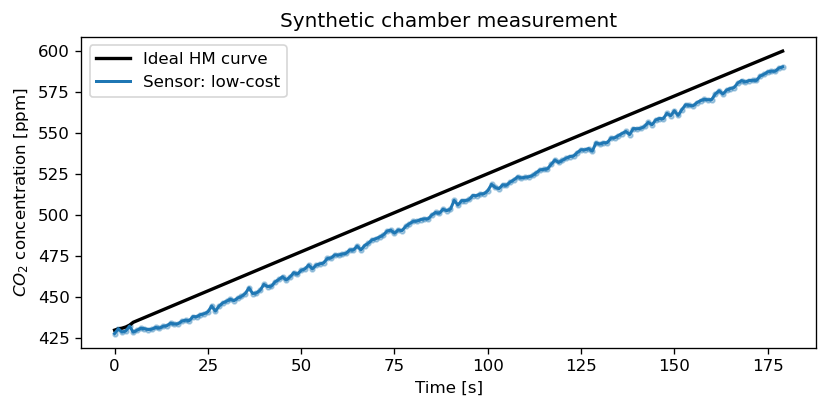

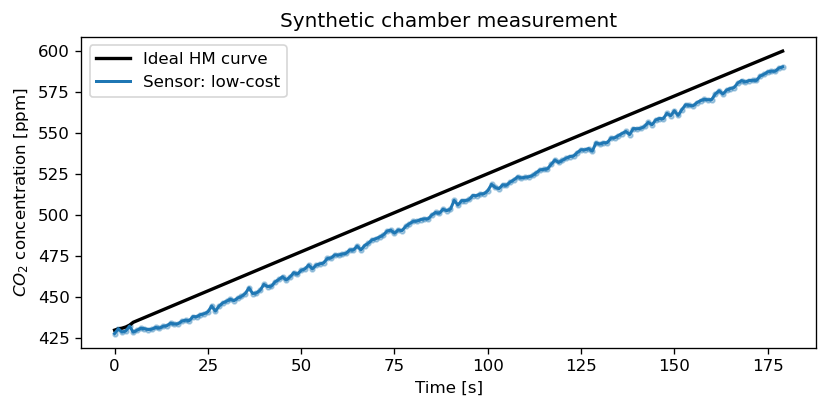

In [11]:
example_config = make_synthetic_config(
    total_time=180,
    c0=430.0,
    alpha=1.0e-4,
    cs=1.0e4,
    deadband=5,
    curvature="custom",
    sensor_preset="low-cost",
    sensor_precision=1.0,
    random_seed=1,
)

preview_synthetic_config(example_config)

In [12]:
example_file, example_data = save_synthetic_config(
    example_config,
    output_dir=DEFAULT_OUTPUT_DIR / "plain_python_example",
)
example_file

2026-06-02 17:09:39 2026-06-02 17:12:39
File 2026-6-2_17-9-39.json saved


PosixPath('/Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/synthetic/generated/plain_python_example/2026-6-2_17-9-39.json')

## Widget Creator

Use the controls to preview a measurement and save JSON files to `generated/` without editing code.

Output()

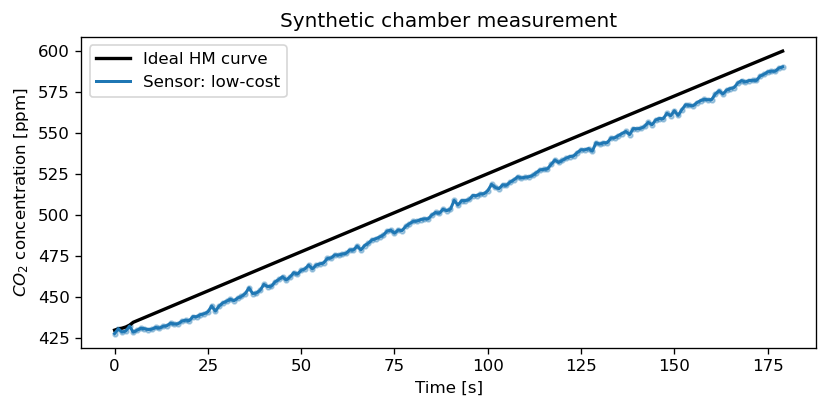

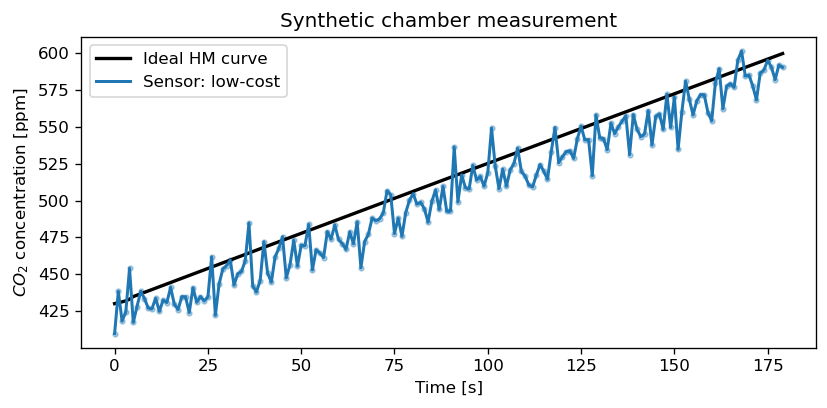

In [13]:
import ipywidgets as widgets
from IPython.display import clear_output, display

style = {"description_width": "150px"}
layout = widgets.Layout(width="420px")

total_time_widget = widgets.IntSlider(value=180, min=30, max=600, step=10, description="Total time [s]", style=style, layout=layout)
c0_widget = widgets.FloatSlider(value=430.0, min=350.0, max=650.0, step=1.0, description="Initial CO2 [ppm]", style=style, layout=layout)
alpha_widget = widgets.FloatLogSlider(value=1.0e-4, base=10, min=-6, max=-2, step=0.1, description="alpha", style=style, layout=layout)
cs_widget = widgets.FloatLogSlider(value=1.0e4, base=10, min=2, max=7, step=0.1, description="c_s", style=style, layout=layout)
deadband_widget = widgets.IntSlider(value=5, min=0, max=60, step=1, description="Deadband [s]", style=style, layout=layout)
curvature_widget = widgets.Dropdown(options=["custom", "linear", "convex"], value="custom", description="Curvature label", style=style, layout=layout)
sensor_preset_widget = widgets.Dropdown(options=list(SENSOR_PRESETS), value="low-cost", description="Sensor preset", style=style, layout=layout)
sensor_precision_widget = widgets.FloatSlider(value=SENSOR_PRESETS["low-cost"]["sensor_precision"], min=0.0, max=10.0, step=0.1, description="Sensor precision", style=style, layout=layout)
seed_widget = widgets.IntText(value=1, description="Random seed", style=style, layout=layout)
output_widget = widgets.Text(value=str(DEFAULT_OUTPUT_DIR), description="Output folder", style=style, layout=widgets.Layout(width="620px"))

preview_button = widgets.Button(description="Preview", button_style="primary")
save_button = widgets.Button(description="Save JSON", button_style="success")
output = widgets.Output()


def on_sensor_preset_changed(change):
    preset = change["new"]
    if preset == "perfect":
        sensor_precision_widget.disabled = True
        return
    sensor_precision_widget.disabled = False
    sensor_precision_widget.value = SENSOR_PRESETS[preset]["sensor_precision"]


sensor_preset_widget.observe(on_sensor_preset_changed, names="value")


def config_from_widgets():
    return make_synthetic_config(
        total_time=total_time_widget.value,
        c0=c0_widget.value,
        alpha=alpha_widget.value,
        cs=cs_widget.value,
        deadband=deadband_widget.value,
        curvature=curvature_widget.value,
        sensor_preset=sensor_preset_widget.value,
        sensor_precision=None if sensor_preset_widget.value == "perfect" else sensor_precision_widget.value,
        random_seed=seed_widget.value,
    )


def show_equivalent_code(config):
    print("Equivalent Python call:")
    print(
        "config = make_synthetic_config("
        f"total_time={config['total_time']}, "
        f"c0={config['c_c0']}, "
        f"alpha={config['alpha']:.6g}, "
        f"cs={config['c_s']:.6g}, "
        f"deadband={config['deadband']}, "
        f"curvature={config['curvature']!r}, "
        f"sensor_preset={config.get('sensor_preset', 'perfect')!r}, "
        f"sensor_precision={config.get('sensor_settings', {}) and config['sensor_settings']['sensor_precision']!r}, "
        f"random_seed={seed_widget.value})"
    )
    if config.get("sensor_settings"):
        print("Sensor settings:")
        for key, value in config["sensor_settings"].items():
            print(f"  {key}: {value}")


def on_preview_clicked(_):
    with output:
        clear_output(wait=True)
        config = config_from_widgets()
        show_equivalent_code(config)
        display(preview_synthetic_config(config))


def on_save_clicked(_):
    with output:
        clear_output(wait=True)
        config = config_from_widgets()
        path, _ = save_synthetic_config(config, pathlib.Path(output_widget.value))
        show_equivalent_code(config)
        display(preview_synthetic_config(config))
        print(f"Saved: {path}")


preview_button.on_click(on_preview_clicked)
save_button.on_click(on_save_clicked)

controls = widgets.VBox([
    total_time_widget,
    c0_widget,
    alpha_widget,
    cs_widget,
    deadband_widget,
    curvature_widget,
    sensor_preset_widget,
    sensor_precision_widget,
    seed_widget,
    output_widget,
    widgets.HBox([preview_button, save_button]),
])

display(controls, output)
on_preview_clicked(None)